<a href="https://colab.research.google.com/github/ThayseBachmeyer/ProcessamentoSinaisI/blob/main/aula1408.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import numpy as np
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt





In [ ]:
def calculate_spectrum(signal, sampling_frequency, single_sided=True):
    """
    Calculates the amplitude spectrum of a signal.

    Args:
        signal (np.ndarray): The time-domain signal.
        sampling_frequency (float): The sampling frequency of the signal (Hz).
        single_sided (bool): If True, returns the single-sided spectrum (positive frequencies).
                             If False, returns the full spectrum (positive and negative frequencies).

    Returns:
        tuple: A tuple containing:
            - frequencies (np.ndarray): Array of frequencies (Hz).
            - amplitudes (np.ndarray): Array of corresponding amplitude magnitudes.
    """
    N = len(signal) # Number of sample points
    T = 1.0 / sampling_frequency # Sample spacing

    # Perform the FFT
    yf = fft(signal)

    if single_sided:
        xf = fftfreq(N, T)[:N//2] # Frequencies for the positive half of the spectrum
        # Calculate the single-sided amplitude spectrum
        # np.abs(yf[0:N//2]) gets the magnitude of the positive frequencies
        amplitudes = 1.0/N * np.abs(yf[0:N//2])
    else:
        xf = fftfreq(N, T) # All frequencies
        amplitudes = 1.0/N * np.abs(yf)

    return xf, amplitudes

In [ ]:
sampling_frequency = 44100 # Hz
duration = 5 # seconds
t = np.linspace(0.0, duration, int(sampling_frequency * duration), endpoint=False)

frequency1 = 500 # Hz
frequency2 = 5000 # Hz


signal = 0.7 * np.cos(2 * np.pi * frequency1 * t) + \
         1.0 * np.cos(2 * np.pi * frequency2 * t) + \
         0.3 * np.random.randn(len(t)) # Add some noise

In [ ]:
sampling_frequency = 44100 # Hz
duration = 5 # seconds
t = np.linspace(0.0, duration, int(sampling_frequency * duration), endpoint=False)

frequency1 = 500 # Hz
frequency2 = 5000 # Hz
frequency3 = 10000

signal = 0.7 * np.cos(2 * np.pi * frequency1 * t) + \
         1.0 * np.cos(2 * np.pi * frequency2 * t) + \
         0.5 * np.cos(2 * np.pi * frequency3 * t )+ \
         0.3 * np.random.randn(len(t)) # Add some noise

In [ ]:

frequencies_single_sided, amplitudes_single_sided = calculate_spectrum(signal, sampling_frequency, single_sided=True)
frequencies_full, amplitudes_full = calculate_spectrum(signal, sampling_frequency, single_sided=False)

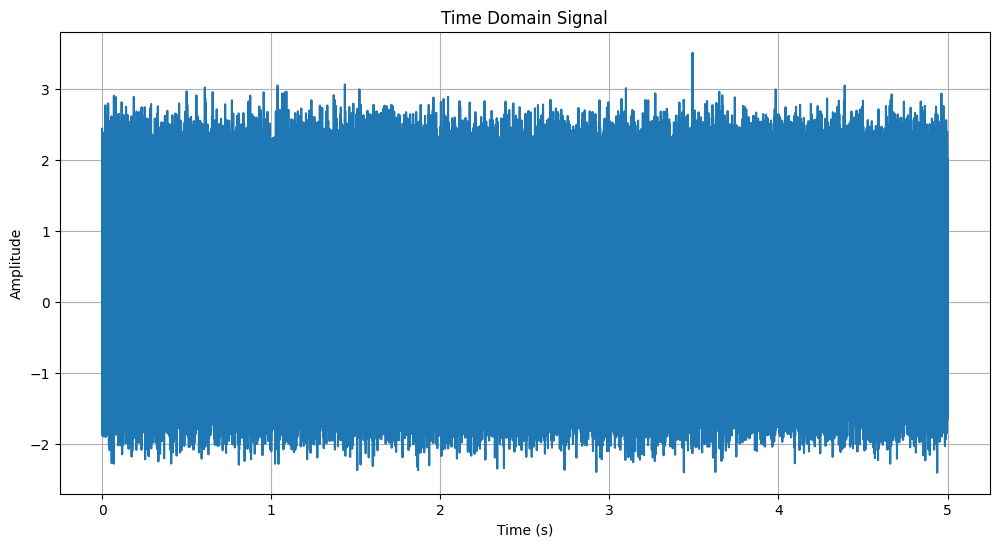

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(t, signal)
plt.title('Time Domain Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)

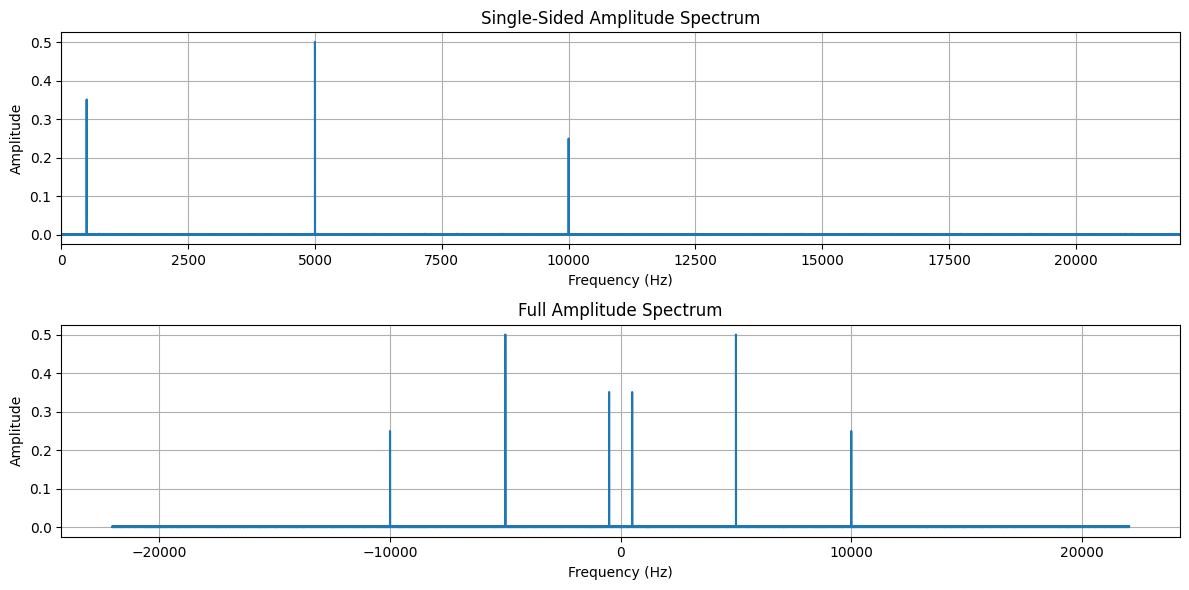

In [ ]:
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(frequencies_single_sided, amplitudes_single_sided)
plt.title('Single-Sided Amplitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, sampling_frequency / 2) # Show frequencies up to Nyquist

plt.subplot(2, 1, 2)
plt.plot(frequencies_full, amplitudes_full)
plt.title('Full Amplitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.tight_layout()
plt.show()

### Gráficos de $x(t)$ para Frequências Específicas

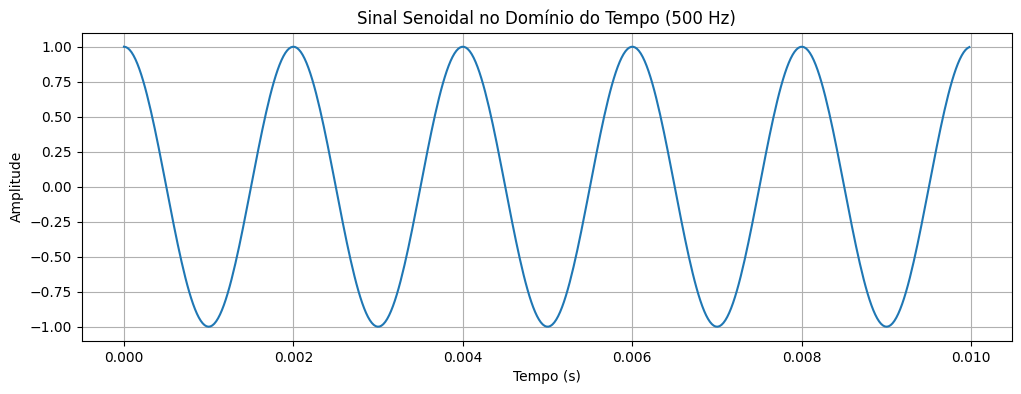

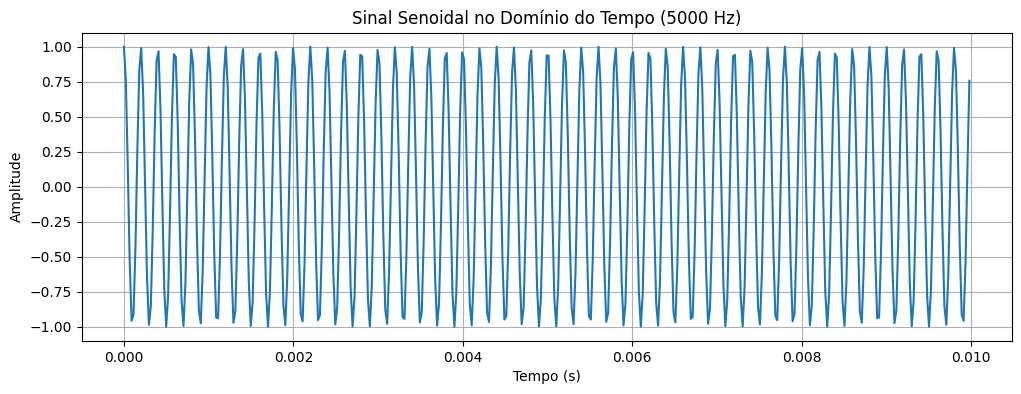

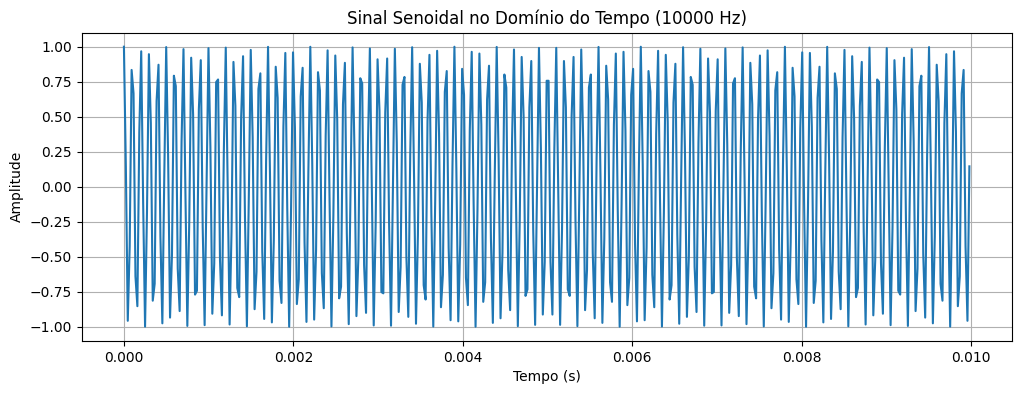

In [ ]:
frequencies_to_plot = [500, 5000, 10000]

sampling_frequency = 44100 # Hz
duration = 0.01 # seconds

# t = np.linspace(0.0, duration, int(sampling_frequency * duration), endpoint=False)
t = np.arange(0,duration,1/sampling_frequency, dtype=float)

for freq in frequencies_to_plot:
    # Generate a cosine signal for the current frequency
    signal_to_plot = 1.0 * np.cos(2 * np.pi * freq * t)

    plt.figure(figsize=(12, 4))
    plt.plot(t, signal_to_plot)
    plt.title(f'Sinal Senoidal no Domínio do Tempo ({freq} Hz)')
    plt.xlabel('Tempo (s)')
    plt.ylabel('Amplitude')
    plt.grid(True)
    plt.show()


<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

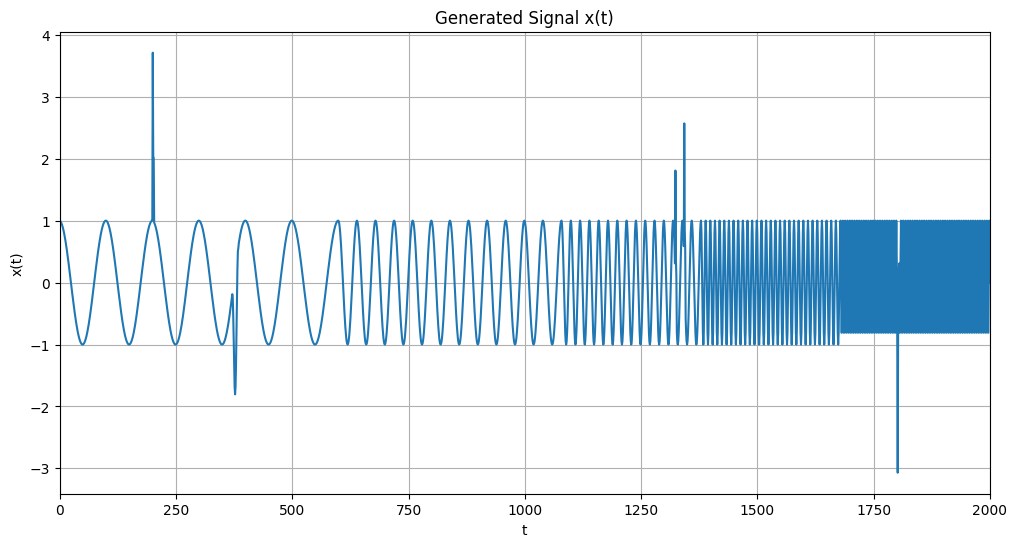

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

N = 2000                                             # Signal length
t = np.arange(N + 1)                                 # Time values
x = np.zeros_like(t, dtype=np.float64)               # Initialize x as float to allow for sin wave additions

pos_sin = np.array([0, 600, 1080, 1380, 1680, 2000]) # Initial position for each sinusoid function
T_sin = np.array([100, 40, 20, 10, 5])               # Sampling period of each sinusoid function

for i in range(5):
    m = pos_sin[i]
    n = pos_sin[i+1]

    segment_length = n - m
    t_segment_values = np.arange(1, segment_length + 1)

    x[m:n] = np.cos(2*np.pi*t_segment_values/T_sin[i])

amp_imp = np.array([3, -2, 2, 2.5, -2.5])
pos_imp = np.array([200, 372, 1324, 1343, 1802])
T_imp = np.array([5, 25, 5, 5, 5])

for i in range(5):
    m = pos_imp[i]
    relative_end_offset = int(T_imp[i] / 2)
    n = pos_imp[i] + relative_end_offset

    segment_length = n - m + 1
    t_segment_values = np.arange(1, segment_length + 1)

    x[m:n+1] += amp_imp[i] * (np.sin(2 *np.pi*t_segment_values/T_imp[i]))**2

    plt.figure(figsize=(12, 6))
plt.plot(t, x)
plt.title('Generated Signal x(t)')
plt.xlabel('t')
plt.ylabel('x(t)')
plt.xlim(0, N)
plt.grid(True)
plt.show()


In [ ]:
# n°1

import numpy as np
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt
import IPython.display
from IPython.display import Audio, display


frequencies_to_plot = [500, 5000, 10000]

sampling_frequency = 44100 # Hz
duration_plot = 0.01 # seconds
duration_au = 1

t = np.arange(0, duration_plot, 1/sampling_frequency, dtype=float)
t_au = np.arange(0, duration_au, 1/sampling_frequency, dtype=float)

for freq in frequencies_to_plot:
    # Generate a cosine signal for the current frequency
    signal_to_plot = 1 * np.cos(2 * np.pi * freq * t)

    plt.figure(figsize=(12, 4))
    plt.plot(t, signal_to_plot)
    plt.title(f'Sinal Senoidal no Domínio do Tempo ({freq} Hz)')
    plt.xlabel('Tempo (s)')
    plt.ylabel('Amplitude')
    plt.grid(True)
    plt.show()

    signal_au = 1 * np.cos(2 * np.pi * freq * t_au)
    print(f"Audio")
    display(Audio(signal_au, rate = sampling_frequency))

In [ ]:
# n°2

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import chirp
from IPython.display import Audio, display

sampling_frequency = 44100
duration  = 0.01
duration_au = 1
t_sig = np.arange(0,  duration, 1/sampling_frequency, dtype=np.float32)
t_au = np.arange(0,  duration_au, 1/sampling_frequency, dtype=np.float32)

signal_chirp = chirp(t_sig, f0=500, f1=10000, t1=duration, method='linear')

plt.figure(figsize=(12, 4))
plt.plot(t_sig, signal_chirp)
plt.title('Sinal')
plt.xlabel('Tempo')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 4))
plt.specgram(signal_chirp, Fs=sampling_frequency, cmap = "plasma")
plt.title('Espectograma')
plt.xlabel('Tempo')
plt.ylabel('Frequência')
plt.grid(True)
plt.show()

signal_au = chirp(t_au, f0=500, f1=10000, t1=duration_au, method='linear')
print('\n audio \n')
display(Audio(signal_au, rate=sampling_frequency))


In [ ]:
# n°3

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from IPython.display import Audio, display
import os

handel = "https://github.com/ThayseBachmeyer/ProcessamentoSinaisI/raw/refs/heads/main/Arquivos/handel.wav"
nome_handel = "Arquivos_handel.wav"

!wget -O {nome_handel} {handel}

sampling_frequency, signal = wavfile.read(nome_handel)

if len(signal.shape) > 1:
  signal = signal[:, 0]

t = len(signal) / sampling_frequency
t_sig = np.linspace(0, t, len(signal))

plt.figure(figsize=(12, 4))
plt.plot(t_sig, signal)
plt.title('Sinal')
plt.xlabel('Tempo')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

plt.figure(figsize=(12,4))
plt.specgram(signal, Fs=sampling_frequency, cmap = "rainbow")
plt.title('Espectograma')
plt.xlabel('Tempo')
plt.ylabel('Frequência')
plt.grid(True)
plt.show()

f0 = int(sampling_frequency)
f1 = int(sampling_frequency * 2)
f2 = int(sampling_frequency * 4)

display(Audio(signal, rate=f0))
display(Audio(signal, rate=f1))
display(Audio(signal, rate=f2))

--2026-08-17 21:09:19--  https://github.com/ThayseBachmeyer/ProcessamentoSinaisI/raw/refs/heads/main/Arquivos/h_banheiro.wav
Resolving github.com (github.com)... 140.82.121.3
Connecting to github.com (github.com)|140.82.121.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/ThayseBachmeyer/ProcessamentoSinaisI/refs/heads/main/Arquivos/h_banheiro.wav [following]
--2026-08-17 21:09:19--  https://raw.githubusercontent.com/ThayseBachmeyer/ProcessamentoSinaisI/refs/heads/main/Arquivos/h_banheiro.wav
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 18994 (19K) [audio/wav]
Saving to: ‘Arquivos_banh.wav’

Arquivos_banh.wav   100%[===================>]  18.55K  --.-KB/s    in 0s      

2026-08-17 21:09:19

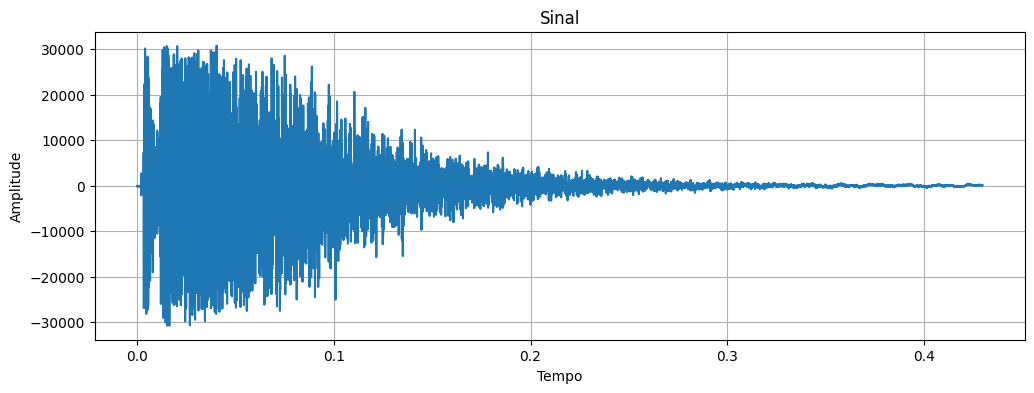

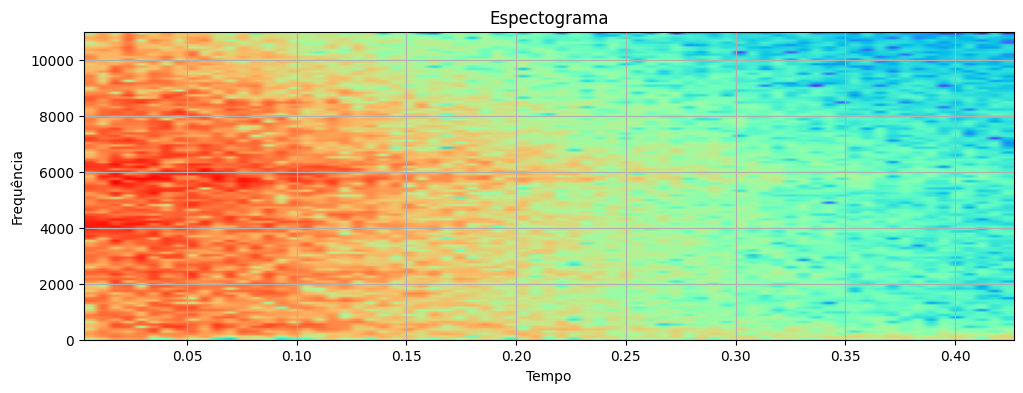

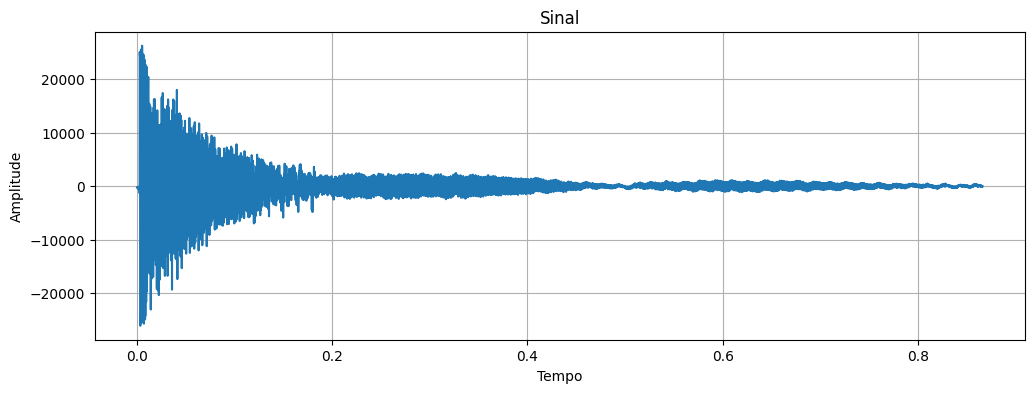

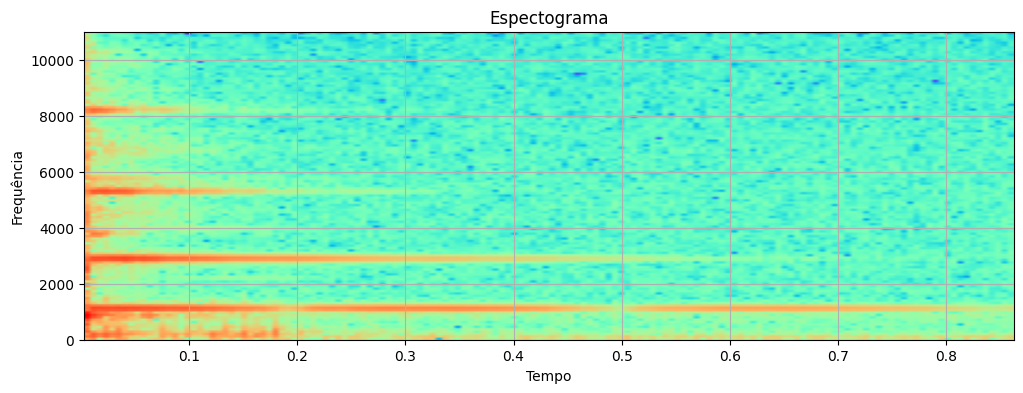

In [3]:
# n°5

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from IPython.display import Audio, display
import os


banh = "https://github.com/ThayseBachmeyer/ProcessamentoSinaisI/raw/refs/heads/main/Arquivos/h_banheiro.wav"
nome_banh = "Arquivos_banh.wav"

taca = "https://github.com/ThayseBachmeyer/ProcessamentoSinaisI/raw/refs/heads/main/Arquivos/sinal_taca.wav"
nome_taca = "Arquivos_taca.wav"


!wget -O {nome_banh} {banh}
!wget -O {nome_taca} {taca}

sampling_frequency_banh, signal_banh = wavfile.read(nome_banh)
sampling_frequency_taca, signal_taca = wavfile.read(nome_taca)

if len(signal_banh.shape) > 1:
  signal_banh = signal_banh[:, 0]

if len(signal_taca.shape) > 1:
  signal_taca = signal_taca[:, 0]


t_banh = len(signal_banh) / sampling_frequency_banh
t_taca = len(signal_taca) / sampling_frequency_taca

t_sig_banh = np.linspace(0, t_banh, len(signal_banh))
t_sig_taca = np.linspace(0, t_taca, len(signal_taca))


plt.figure(figsize=(12, 4))
plt.plot(t_sig_banh, signal_banh)
plt.title('Sinal')
plt.xlabel('Tempo')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

plt.figure(figsize=(12,4))
plt.specgram(signal_banh, Fs=sampling_frequency_banh, cmap = "rainbow")
plt.title('Espectograma')
plt.xlabel('Tempo')
plt.ylabel('Frequência')
plt.grid(True)
plt.show()


display(Audio(signal_banh, rate=sampling_frequency_banh))


plt.figure(figsize=(12, 4))
plt.plot(t_sig_taca, signal_taca)
plt.title('Sinal')
plt.xlabel('Tempo')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

plt.figure(figsize=(12,4))
plt.specgram(signal_taca, Fs=sampling_frequency_taca, cmap = "rainbow")
plt.title('Espectograma')
plt.xlabel('Tempo')
plt.ylabel('Frequência')
plt.grid(True)
plt.show()


display(Audio(signal_taca, rate=sampling_frequency_taca))

--2026-08-17 21:12:32--  https://github.com/ThayseBachmeyer/ProcessamentoSinaisI/raw/refs/heads/main/Arquivos/h_banheiro.wav
Resolving github.com (github.com)... 140.82.121.3
Connecting to github.com (github.com)|140.82.121.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/ThayseBachmeyer/ProcessamentoSinaisI/refs/heads/main/Arquivos/h_banheiro.wav [following]
--2026-08-17 21:12:32--  https://raw.githubusercontent.com/ThayseBachmeyer/ProcessamentoSinaisI/refs/heads/main/Arquivos/h_banheiro.wav
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 18994 (19K) [audio/wav]
Saving to: ‘Arquivos_banh.wav’

Arquivos_banh.wav   100%[===================>]  18.55K  --.-KB/s    in 0s      

2026-08-17 21:12:32

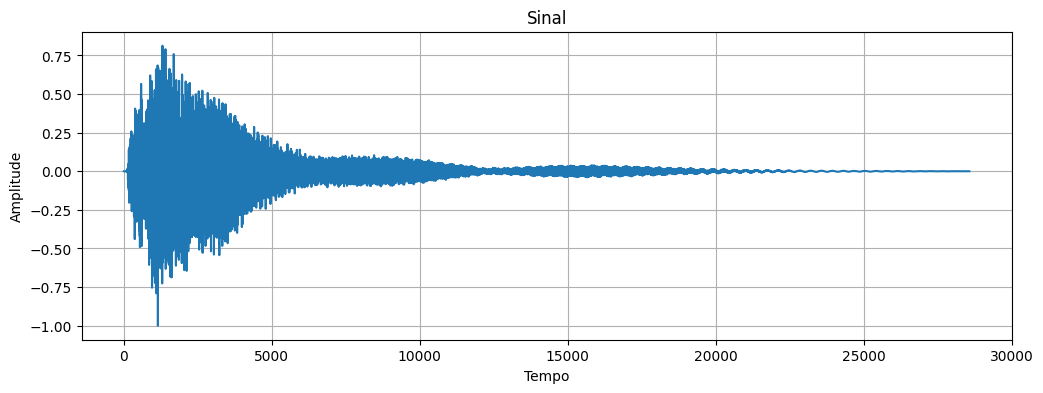

NameError: name 'sampling_frequency' is not defined

In [6]:
# n°6

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import fftconvolve
from IPython.display import Audio, display
import os


banh = "https://github.com/ThayseBachmeyer/ProcessamentoSinaisI/raw/refs/heads/main/Arquivos/h_banheiro.wav"
nome_banh = "Arquivos_banh.wav"

taca = "https://github.com/ThayseBachmeyer/ProcessamentoSinaisI/raw/refs/heads/main/Arquivos/sinal_taca.wav"
nome_taca = "Arquivos_taca.wav"


!wget -O {nome_banh} {banh}
!wget -O {nome_taca} {taca}

sampling_frequency_banh, signal_banh = wavfile.read(nome_banh)
sampling_frequency_taca, signal_taca = wavfile.read(nome_taca)

if len(signal_banh.shape) > 1:
  signal_banh = signal_banh[:, 0]

if len(signal_taca.shape) > 1:
  signal_taca = signal_taca[:, 0]


t_banh = len(signal_banh) / sampling_frequency_banh
t_taca = len(signal_taca) / sampling_frequency_taca

t_sig_banh = np.linspace(0, t_banh, len(signal_banh))
t_sig_taca = np.linspace(0, t_taca, len(signal_taca))

banhtaca = fftconvolve(signal_banh, signal_taca)

banhtaca = banhtaca / np.max(np.abs(banhtaca))

plt.figure(figsize=(12,4))
plt.plot(banhtaca)
plt.title('Sinal')
plt.xlabel('Tempo')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

display(Audio(banhtaca, rate=sampling_frequency))